# Práctica 1 - Detección de Anomalías con Machine Learning
## Lucas Díaz Ruiz - Desarrollo de Software Crítico - Grado en Ingeniería del Software - 3ºA
Disponemos de un fichero con datos de temperaturas registrados en un dispositivo
industrial (datos.csv). Vamos a utilizar diferentes técnicas de Machine Learning para
identificar posibles anomalías en este fichero.
Se muestran a continuación ejemplos de mediciones del fichero y una gráfica con todas
las mediciones:  
  
timestamp -------- value  
2013-07-04 0:00:00,69.88083514  
2013-07-04 1:00:00,71.22022706  
2013-07-04 2:00:00,70.87780496  
2013-07-04 3:00:00,68.95939994
  
…  
  
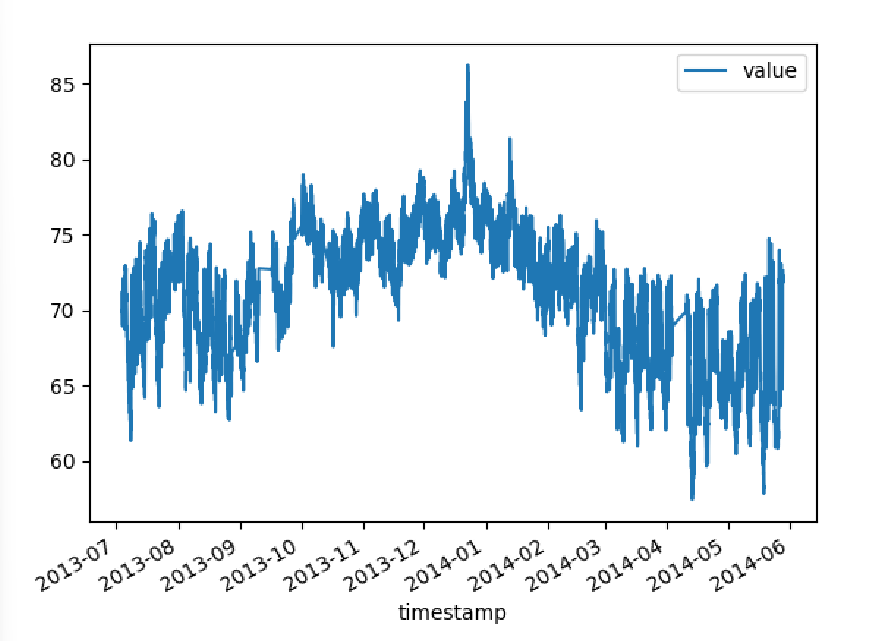

La práctica va a constar de las 3 partes que se mencionan a continuación y el lenguaje
de programación a utilizar será Python.  

**Antes de empezar: la estructura de esta memoria se basa en mostrar un código/plot y a continuación comentar los aspectos relevantes de esa parte**

## 1. Construcción de modelo LSTM y detección de anomalías.  
Empezaré creando la estructura básica para una ejecución normal y luego desarrollaré los apartados a, b y c.

In [ ]:
# Muestra los valores más anómalos del fichero csv suministrado

# Librerías del ejercicio 1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# Librerías del ejercicio 2
from keras.layers import RepeatVector
from keras.layers import TimeDistributed
from keras.layers import Input

# Librerías del ejercicio 3
from sklearn.ensemble import IsolationForest

Importamos las librerías y partes de librerías que serán necesarías para la resolución de la práctica.

                         value
timestamp                     
2013-07-04 00:00:00  69.880835
2013-07-04 01:00:00  71.220227
2013-07-04 02:00:00  70.877805
2013-07-04 03:00:00  68.959400
2013-07-04 04:00:00  69.283551
(7267, 1)



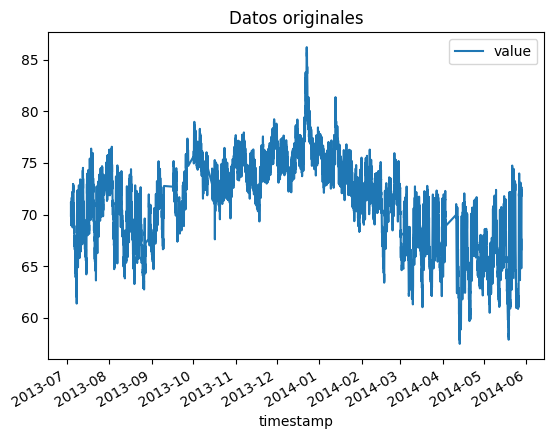

In [ ]:
# ------------------------------------------------------------------------------
# CARGA DE DATOS
# ------------------------------------------------------------------------------

df = pd.read_csv("datos.csv", index_col=0, parse_dates=True)

print(df.head())
print(df.shape); print() # (7267,1) (según el fichero cambiará el número de filas)

df.plot()
plt.title("Datos originales")
plt.show()

Cargamos los datos del 'csv', comprobamos su forma y los mostramos con 'show' el 'plot' creado.

In [ ]:

# ------------------------------------------------------------------------------
# PREPROCESAMIENTO Y CREACIÓN DE VENTANAS
# ------------------------------------------------------------------------------
# Tamaño de la ventana
windows_size = 10

#  Asignamos los datos esta variable
data = df.values

# Crear las ventanas temporales
# Lo que se predice (y) es el "siguiente" valor de la secuencia
# pasando la ventana actual que tenemos.

def split_sequence(data, windows_size):
	X, y = list(), list()
	for i in range(len(data)):
		# find the end of this pattern
		end_ix = i + windows_size
		# check if we are beyond the sequence
		if end_ix > len(data)-1:
			break
		# gather input and output parts of the pattern
		data_x, data_y = data[i:end_ix], data[end_ix]  # Lo que se predice (y) es el "siguiente" valor de la secuencia
		X.append(data_x)
		y.append(data_y)
	return np.array(X),np. array(y)


X, y = split_sequence(data, windows_size)

# Redimensionar los datos para la RNN
# LSTM espera 3 dimensiones: número muestras, pasos temporales, número features
# Ya está dimensionada

n_features = 1

# Comprobamos su forma
print("Forma de X: ", X.shape)  # (nº_muestras, pasos temporales/tam_ventana, features)
print("Forma de Y: ", y.shape); print()

Forma de X:  (7257, 10, 1)
Forma de Y:  (7257, 1)



Establecemos el tamaño de ventana  a 10, creamos la variable con los valores del 'dataframe' y dividimos los datos en ventanas de 10 datos(X) con un valor(y) que será la predicción del siguiente valor de la secuencia.  
En este caso no vamos a dividir los datos, ya que queremos hacer una predicción total de los datos.

In [ ]:
# ------------------------------------------------------------------------------
# CONSTRUCCIÓN DEL MODELO LSTM
# ------------------------------------------------------------------------------
# Crear la RNN(Recurrent Neural Network)
model = Sequential()
model.add(Input(shape=(windows_size, n_features)))
model.add(LSTM(50, activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Crearemos el modelo secuencial con capas 'LSTM' y 'Dense'.   
Este modelo podrá procesar el conjunto de datos y predecir datos secuenciales a largo plazo.

In [ ]:
# ------------------------------------------------------------------------------
# ENTRENAMIENTO
# ------------------------------------------------------------------------------
# Entrenar la RNN
history = model.fit(
    X, y,
    epochs=15,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)


Epoch 1/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.9011 - val_loss: 1.4031
Epoch 2/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.8792 - val_loss: 2.7360
Epoch 3/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.0082 - val_loss: 1.4370
Epoch 4/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.9520 - val_loss: 1.7710
Epoch 5/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.8938 - val_loss: 1.6175
Epoch 6/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 1.1369 - val_loss: 2.3250
Epoch 7/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.0244 - val_loss: 1.7412
Epoch 8/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.9199 - val_loss: 2.0709
Epoch 9/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.9094 - val_loss: 1.2223
Epoch 10/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.9555 - val_loss: 1.3336
Epoch 11/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.9239 - val_loss: 1.2295
Epoch 12/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/ste

Entrenamos el modelo con datos previamente seleccionados.

In [ ]:


# ------------------------------------------------------------------------------
# PREDICCIÓN Y DETECCIÓN DE ANOMALÍAS
# ------------------------------------------------------------------------------
# Hacemos la predicciones
y_pred = model.predict(X)

# Datos sin escalar
y_pred_inv = y_pred # Predicción
y_inv = y           # Valor real

# Calcular el error absoluto medio (MAE-Mean Absolute Error) de los "siguientes" valores de cada secuencia y los valores predichos
mae = np.mean(np.abs(y_pred_inv - y_inv), axis=1)

# Criterio: percentil 99
threshold = np.percentile(mae, 99)
anomalies = mae > threshold

# Mostrar las fechas de las anomalías
# las anomalias se refieren a las ventanas, no a filas específicas dentro de la ventana
fechas_test = df.index[windows_size:]
print(f"El número de anomalías es {np.sum(anomalies)} sobre {len(fechas_test)}")
print("Fechas y valores anómalos detectados:")
anomalies_date_value = df.loc[fechas_test[anomalies]]
print(anomalies_date_value)

227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
El número de anomalías es 73 sobre 7257
Fechas y valores anómalos detectados:
                         value
timestamp                     
2013-07-08 22:00:00  68.885723
2013-07-09 21:00:00  69.720832
2013-07-11 04:00:00  66.495499
2013-07-12 04:00:00  67.431484
2013-07-16 06:00:00  67.990076
...                        ...
2014-05-26 22:00:00  69.023778
2014-05-27 00:00:00  67.101938
2014-05-27 10:00:00  70.100104
2014-05-27 21:00:00  69.750220
2014-05-28 01:00:00  67.000081

[73 rows x 1 columns]


Con el modelo ya entrenado hacemos la predicción.  
Calculamos el error absoluto medio con la predicción realizada y los valores reales.  Para detectar anomalías usé el criterio del percentil 99.
Aunque, al comienzo de la práctica empleé el percentil 95, pero obtenía demasiadas anomalías, en concreto 363, tras el cambio obtuve 73, el cual, es un número más cercano a la gráfica del enunciado.  
Y por último mostramos el número de anomalías y cada anomalía asociada a su valor

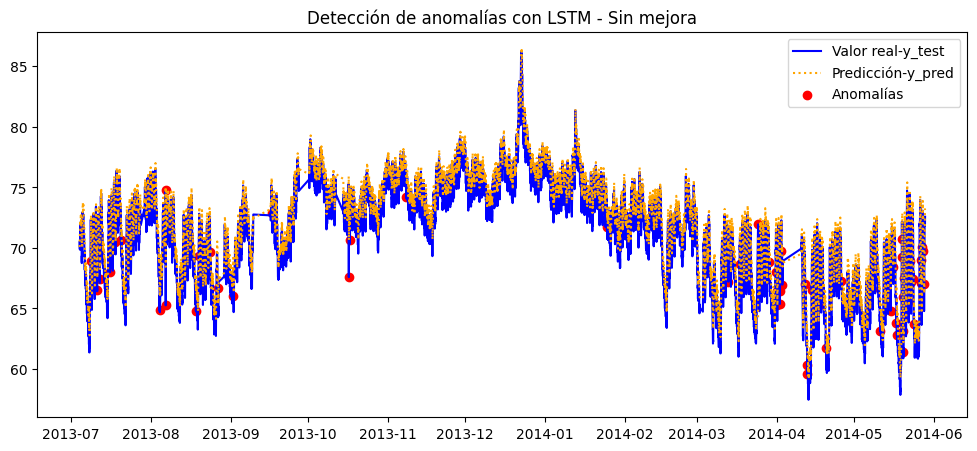

In [ ]:
# ------------------------------------------------------------------------------
# GRAFICAR RESULTADOS
# ------------------------------------------------------------------------------
# Mostrar la gráfica con las anomalías
plt.figure(figsize=(12,5))
plt.plot(fechas_test, y_inv, color='blue', label='Valor real-y_test')
plt.plot(fechas_test, y_pred_inv, color='orange', linestyle='dotted',label='Predicción-y_pred')
plt.scatter(fechas_test[anomalies], y_inv[anomalies], color='red', label='Anomalías')
plt.legend()
plt.title("Detección de anomalías con LSTM - Sin mejora")
plt.show()


Por último mostramos en la gráfica los valores reales(línea continua azul), la predicción de estos(línea discontinua naranaja) y las anomalías(punto rojo).

Podemos observar que la predicción está un poco más elevada que los datos reales, por lo tanto detecta muchas más ventanas anómalas a la baja que a la alta.  
Pero no obtenemos un resultado gráfico parecido, lo intentaremos mejorar en el apartado c.

### a. Construcción de modelo básico LSTM.
En este apartado se construirá un modelo con redes LSTM. La red tomará como entrada
secuencias de datos (ventanas) del fichero con un tamaño determinado, por
ejemplo [69.88, 71.22, 70.87] y devolverá una predicción del siguiente valor
de la secuencia (p.ej. [68.86]).  
En este caso para no tener que usar otro modelo ampliaré la ventana de tamaño
3 a 10, para poder usar el modelo inicial. Como ventana usaré los 10 primeros datos para predecir el undécimo

In [ ]:
# ------------------------------------------------------------------------------
# Ej1 - Apartado A: Predicción del valor siguiente de una secuencia conocida
# de tamaño 3
# ------------------------------------------------------------------------------

# Convertimos el arr en arr de numpy y lo convertimos en una matriz de 1x10x1(samples, win_size, ) para la predicción
ventana_ej1 = np.array([69.88, 71.22, 70.87, 68.95, 68.28, 70.06, 69.27, 69.36, 69.16, 68.98]).reshape(1, windows_size, 1)
# Prediccion
prediccion_ej1 = model.predict(ventana_ej1, verbose=0)

print(f"El siguiente valor de la ventana {ventana_ej1.flatten()} es: {prediccion_ej1.flatten()}")
print(f"Su valor real es: {69.96} => Error: {np.abs(prediccion_ej1.flatten() - 69.96)}")

El siguiente valor de la ventana [69.88 71.22 70.87 68.95 68.28 70.06 69.27 69.36 69.16 68.98] es: [70.10033]
Su valor real es: 69.96 => Error: [0.14032745]


### b. Detección de anomalías.
Una vez está el modelo entrenado, si le
pasamos una nueva ventana, por ejemplo [71.88, 70.22, 72.87], nos
devolverá la predicción del siguiente valor de la secuencia (p.ej. [72.3]).

Vamos a aprovechar esto para detectar anomalías en el fichero. Habrá que
determinar un criterio para identificar las anomalías y aplicarlo al fichero de
datos para que se muestren las mismas, tanto en forma textual como gráfica.  

Como en el apartado a, usaremos una ventana de 10 en vez de 3, para no reusar el modelo. En este caso con 10 datos nuevos.

In [ ]:
# ------------------------------------------------------------------------------
# Ej1 - Apartado B: Predicción del valor siguiente de una nueva secuencia de
# datos de tamaño 3
# ------------------------------------------------------------------------------

# Convertimos el arr en arr de numpy y lo convertimos en una matriz de 1x10x1(samples, win_size, ) para la predicción
ventana_ej2 = np.array([71.45, 70.88, 72.31, 71.96, 70.55, 72.77, 71.12, 72.49, 70.93, 71.68]).reshape(1, windows_size, 1)
# Predicción
prediccion_ej2 = model.predict(ventana_ej2, verbose=0)

print(f"El siguiente valor de la ventana {ventana_ej2.flatten()} es: {prediccion_ej2.flatten()}")

El siguiente valor de la ventana [71.45 70.88 72.31 71.96 70.55 72.77 71.12 72.49 70.93 71.68] es: [72.4165]


### c. Mejora del modelo.
El estudiante debe intentar mejorar el modelo
inicialmente desarrollado aplicando 2 cambios. Por ejemplo, se puede usar
escalado de datos (MinMaxScaler), cambiar la estructura de la red, el tamaño
de las ventanas o incorporar más características en el modelo de
entrenamiento. Un ejemplo de más características en el modelo puede ser la
incorporación en el dataframe de hora del día, día de la semana, etc. Como
resultado final se debe indicar qué aspectos se han modificado y un análisis
de los resultados obtenidos.

Forma de X:  (7257, 10, 1)
Forma de Y:  (7257, 1)



Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_10 (LSTM)                  │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 3289.2070 - val_loss: 229.9562
Epoch 2/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 33.4007 - val_loss: 10.5701
Epoch 3/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.9727 - val_loss: 9.6068
Epoch 4/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.8431 - val_loss: 10.7749
Epoch 5/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.8030 - val_loss: 10.1850
Epoch 6/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 4.1163 - val_loss: 9.5318
Epoch 7/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 3.6192 - val_loss: 9.4356
Epoch 8/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.5049 - val_loss: 9.8166
Epoch 9/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.7098 - val_loss: 8.6667
Epoch 10/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.6181 - val_loss: 8.8926
Epoch 11/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.6542 - val_loss: 8.1955
Epoch 12/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 1

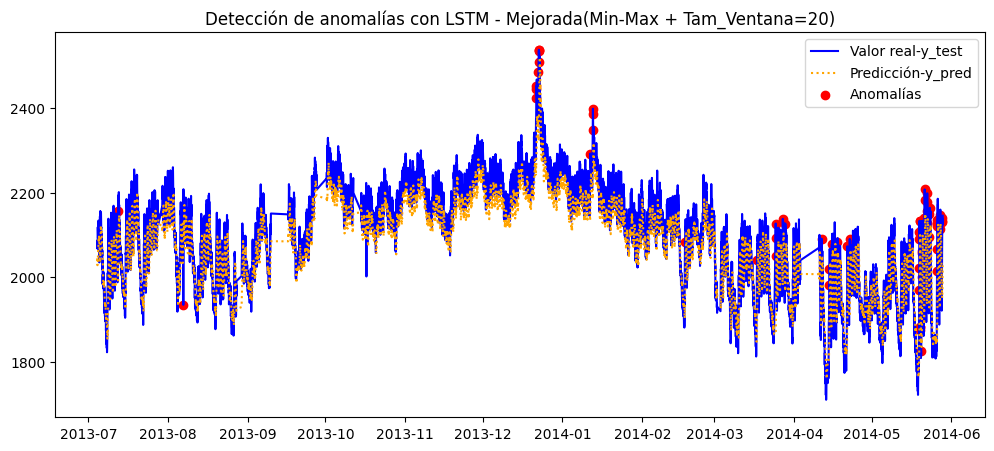

In [ ]:
#-------------------------------------------------------------------------------
# PREPROCESAMIENTO Y CREACIÓN DE VENTANAS
# ------------------------------------------------------------------------------
# Tamaño de la ventana
windows_size = 10

#  Asignamos los datos esta variable
data = df.values
# Normalizar los datos (las redes LSTM aprenden mejor con datos escalados)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(df.values)

n_features = 1

# Crear las ventanas temporales
# Lo que se predice (y) es el "siguiente" valor de la secuencia
# pasando la ventana actual que tenemos.

def split_sequence(data, data_scaled, windows_size):
	X, y = list(), list()
	for i in range(len(data)):
		# find the end of this pattern
		end_ix = i + windows_size
		# check if we are beyond the sequence
		if end_ix > len(data)-1:
			break
		# gather input and output parts of the pattern
		data_x, data_y = data_scaled[i:end_ix], data[end_ix]  # Lo que se predice (y) es el "siguiente" valor de la secuencia
		X.append(data_x)
		y.append(data_y)
	return np.array(X),np. array(y)


X, y = split_sequence(data, data_scaled, windows_size)

n_features = 1

# Comprobamos la forma de los datos
print("Forma de X: ", X.shape)  # (nº_muestras, pasos temporales/tam_ventana, features)
print("Forma de Y: ", y.shape); print()


# ------------------------------------------------------------------------------
# CONSTRUCCIÓN DEL MODELO LSTM
# ------------------------------------------------------------------------------
# Crear la RNN(Recurrent Neural Network)
model = Sequential()
model.add(Input(shape=(windows_size, n_features)))
model.add(LSTM(50, activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
model.summary()

# ------------------------------------------------------------------------------
# ENTRENAMIENTO
# ------------------------------------------------------------------------------
# Entrenar la RNN
history = model.fit(
    X, y,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# ------------------------------------------------------------------------------
# PREDICCIÓN Y DETECCIÓN DE ANOMALÍAS
# ------------------------------------------------------------------------------
# Un posible criterio de anomalía
# Calcular el error absoluto medio (MAE) de los "siguientes" valores de cada secuencia y los valores predichos

# Hacemos la predicciones
y_pred = model.predict(X)

# Escalado MinMax
# Invertimos la escala para obtener valores originales
y_pred_inv = scaler.inverse_transform(y_pred)
y_inv = scaler.inverse_transform(y)

# Calcular el promedio del MAE(Mean Absolute Error)
mae = np.mean(np.abs(y_pred_inv - y_inv), axis=1)

# Criterios: percentiles o doble o triple del mae
#threshold = 2 * mae
#threshold = 3* mae
threshold = np.percentile(mae, 99)
anomalies = mae > threshold

# Mostrar las fechas de las anomalías
# las anomalias se refieren a las ventanas, no a filas específicas dentro de la ventana
fechas_test = df.index[windows_size:]
print(f"El número de anomalías es {np.sum(anomalies)} sobre {len(fechas_test)}")
print("Fechas y valores anómalos detectados:")
anomalies_date_value = df.loc[fechas_test[anomalies]]
print(anomalies_date_value)

# -------------------------------------------------------------------------------------------------
# GRAFICAR RESULTADOS
# -------------------------------------------------------------------------------------------------
# Mostrar la gráfica con las anomalías
plt.figure(figsize=(12,5))
plt.plot(fechas_test, y_inv, color='blue', label='Valor real-y_test')
plt.plot(fechas_test, y_pred_inv, color='orange', linestyle='dotted',label='Predicción-y_pred')
plt.scatter(fechas_test[anomalies], y_inv[anomalies], color='red', label='Anomalías')
plt.legend()
plt.title("Detección de anomalías con LSTM - Mejorada(Min-Max + Tam_Ventana=20)")
plt.show()

Modificaciones al código(2):escalado de los datos con Min-Max y aumentar el tamaño de la ventana de 10 a 20.

Podemos observar que la predicción está debajo de los datos reales. Con este movimiento nos acercamos un poco más a la gráfica de resultado. En este caso predecimos mejor las anomalías altas, pero no consigue detectar del todo las anteriores anomalías bajas del modelo sin mejorar.  

Por lo tanto hemos conseguido mejorar relativamente la detección de anomalías. Para mejorarlo definitivamente necesitaríamos una predicción un poco más elevada, pero igualmente atrasada de los datos reales.



## 2. Autoencoder:   
Trabajando sobre los mismos datos del apartado anterior, se debe construir un modelo
basado en autoencoders para la detección de anomalías. Se deben mostrar los mismos
resultados que en el apartado anterior en cuanto a fechas de las anomalías y una gráfica
donde se puedan identificar. El resultado (gráfico) debe ser similar al siguiente:

                         value
timestamp                     
2013-07-04 00:00:00  69.880835
2013-07-04 01:00:00  71.220227
2013-07-04 02:00:00  70.877805
2013-07-04 03:00:00  68.959400
2013-07-04 04:00:00  69.283551
(7267, 1)



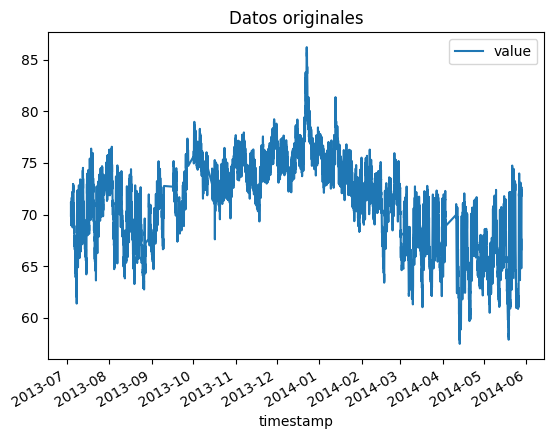

In [ ]:
# ------------------------------------------------------------------------------
# CARGA DE DATOS
# ------------------------------------------------------------------------------
print(df.head())
print(df.shape); print() # (7267,1) (según el fichero cambiará el número de filas)

df.plot()
plt.title("Datos originales")
plt.show()

# Asignamos los datos
data = df.values


Cargamos los datos, pero esta vez no los escalamos.

In [ ]:
# ------------------------------------------------------------------------------
# PREPROCESAMIENTO Y CREACIÓN DE VENTANAS
# ------------------------------------------------------------------------------
# Establecemos el tamaño de ventanas y el número de características
windows_size = 10
n_features = 1

# Normalizar los datos (las redes LSTM aprenden mejor con datos escalados)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Redimensionamos el cojunto de datos con esta función
def create_sequences(data, windows_size):
  sequences = []
  for i in range(len(data) - windows_size):
    seq = data[i:(i+windows_size)]
    sequences.append(seq)
  return np.array(sequences)

X_2 = create_sequences(data_scaled, windows_size)
# Comprobamos la dimensión de los datos
print("(nº de muestras, tamaño de ventana, nº de características):")
print(X_2.shape)

(nº de muestras, tamaño de ventana, nº de características):
(7257, 10, 1)


Creamos la secuencia de ventanas con las dimensiones requeridas.

In [ ]:
# ------------------------------------------------------------------------------
# CONSTRUCCIÓN DEL MODELO LSTM
# ------------------------------------------------------------------------------
# Definimos el modelo
model = Sequential()
model.add(Input(shape=(windows_size, n_features)))
model.add(LSTM(100, activation='relu'))
model.add(RepeatVector(windows_size))
model.add(LSTM(100, activation='relu', return_sequences=True))
model.add(TimeDistributed(Dense(1)))

model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_13 (LSTM)                  │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_2 (RepeatVector)  │ (None, 10, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 10, 100)        │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 10, 1)          │           101 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,301 (473.83 KB)

 Trainable params: 121,301 (473.83 KB)

 Non-trainable params: 0 (0.00 B)

Construcción del modelo Autoenconder.

In [ ]:
# ------------------------------------------------------------------------------
# ENTRENAMIENTO
# ------------------------------------------------------------------------------
# Entrenamos el modelo
# Compara el siguiente dato con el dato actual todo el rato
model.fit(X_2, X_2, epochs=10, verbose=1)


Epoch 1/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.0543
Epoch 2/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0011
Epoch 3/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 6.7993e-04
Epoch 4/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 5.3847e-04
Epoch 5/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 5.2166e-04
Epoch 6/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 5.0908e-04
Epoch 7/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 4.9871e-04
Epoch 8/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 5.0273e-04
Epoch 9/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 4.9041e-04
Epoch 10/10
227/227 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 4.6908e-04


Entrenamiento del modelo.

In [ ]:
# ------------------------------------------------------------------------------
# PREDICCIÓN Y DETECCIÓN DE ANOMALÍAS
# ------------------------------------------------------------------------------
y_hat = model.predict(X_2, verbose=0)

# Calcular el promedio del MAE(Mean Absolute Error)
mae = np.mean(np.abs(y_hat - X_2), axis=(1,2))

# Criterios: percentil
threshold = np.percentile(mae, 99)
anomalies = mae > threshold

# Mostrar las fechas de las anomalías
# las anomalias se refieren a las ventanas, no a filas específicas dentro de la ventana
fechas_test = df.index[windows_size:]

# Valores reales y predichos (último timestep y primera feature)
# Elegimos el último valor real todas las muestras para la primera característica
y_real = X_2[:, -1, 0]
y_pred = y_hat[:, -1, 0]

print(f"El número de anomalías es {np.sum(anomalies)} sobre {len(fechas_test)}")
print("Fechas y valores anómalos detectados:")
anomalies_date_value = df.loc[fechas_test[anomalies]]
print(anomalies_date_value)


El número de anomalías es 73 sobre 7257
Fechas y valores anómalos detectados:
                         value
timestamp                     
2013-07-09 00:00:00  68.421987
2013-08-06 21:00:00  74.762234
2013-08-06 22:00:00  73.495254
2013-08-06 23:00:00  73.365385
2013-08-07 00:00:00  72.597673
...                        ...
2014-05-27 13:00:00  72.680780
2014-05-27 17:00:00  73.087685
2014-05-27 18:00:00  71.322438
2014-05-28 12:00:00  72.172956
2014-05-28 13:00:00  72.046565

[73 rows x 1 columns]


Hacemos la predicción y preparamos las variables de predicción y realidad para graficar los resultados.  

Primero haremos una comparación entre los datos reales y la predicción del autoencoder. Posteriormente usaremos estos para detectar anomalías como en el ejercicio 1.

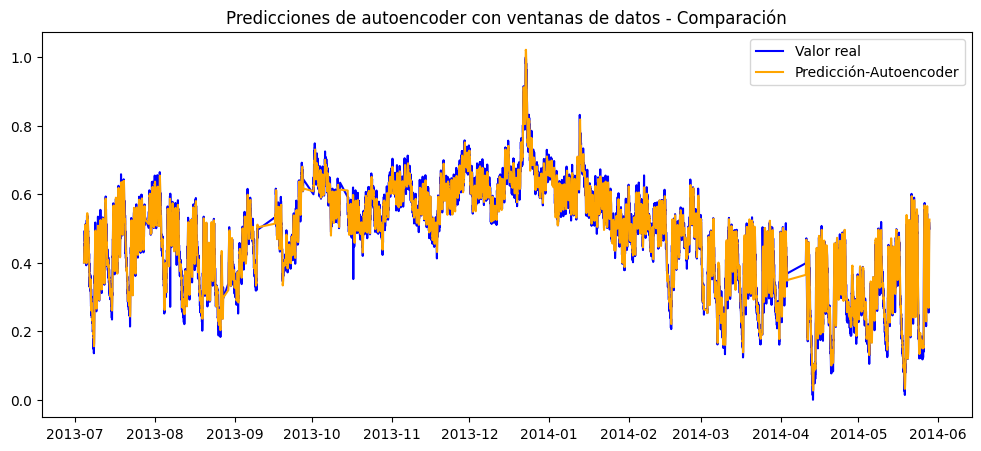

Error cuadrático medio: 0.0004600928408278113


In [ ]:
# ------------------------------------------------------------------------------
# GRAFICAR RESULTADOS - COMPARACIÓN
# ------------------------------------------------------------------------------
plt.figure(figsize=(12,5))
# Último(-1) valor real de todas las muestras(:) para la primera característica(0)
plt.plot(fechas_test, y_real, color='blue', label='Valor real')
# Último(-1) valor predicho por el modelo para cada muestra(:) para la primera característica(0)
plt.plot(fechas_test, y_pred, color='orange',label='Predicción-Autoencoder')
plt.legend()
plt.title("Predicciones de autoencoder con ventanas de datos - Comparación")
plt.show()

print(f"Error cuadrático medio: {np.mean((X_2 - y_hat)**2)}")

En esta gráfica podemos comparar los valores reales y la descompresión de todo el conjunto de datos hecha por el autoencoder. Pudiendo observar un error cuadrático medio muy bajo.   
Las líneas tienen el mismo estilo(opacas) para poder ver como se coloca la predicción encima de los valores reales.

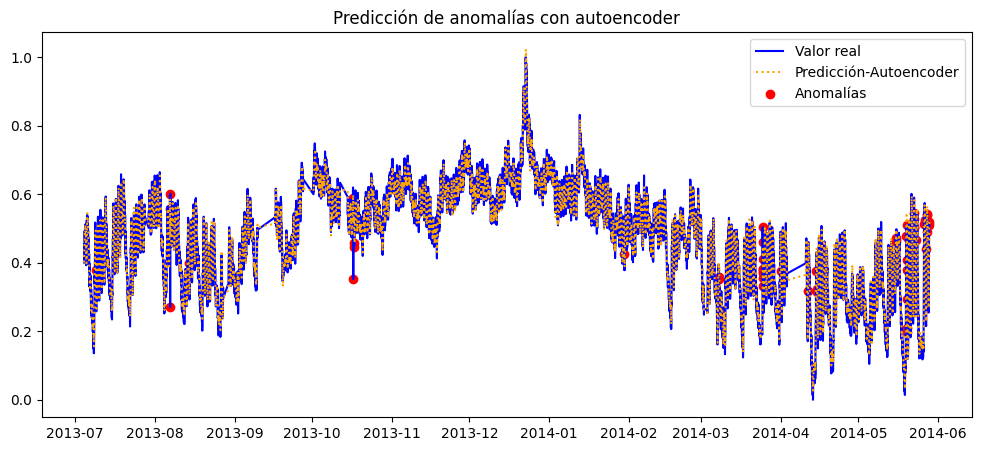

In [ ]:
# ------------------------------------------------------------------------------
# GRAFICAR RESULTADOS - DETECCIÓN DE ANOMALÍAS
# ------------------------------------------------------------------------------
# Ahora detectaremos las anomalías usando la predicción del autoenconder
plt.figure(figsize=(12,5))
plt.plot(fechas_test, y_real, color='blue', label='Valor real')
plt.plot(fechas_test, y_pred, color='orange', linestyle='dotted', label='Predicción-Autoencoder')
plt.scatter(fechas_test[anomalies], y_real[anomalies], color='red', label='Anomalías')
plt.title("Predicción de anomalías con autoencoder")
plt.legend()
plt.show()

Al ser tan parecidas(MSE muy bajo) se detectan algunas ventanas anómalas, pero no en las mismas fechas que usando el model de LSTM.  
No pude obtener un resultado gráfico muy parecido.

## 3. Isolation forest: Trabajando sobre los mismos datos del apartado anterior, se debe utilizar la técnica de
IsolationForest para la detección de anomalías. Se deben mostrar los mismos resultados
que en el apartado anterior en cuanto a fechas de las anomalías y una gráfica donde se
puedan identificar. El resultado (gráfico) debe ser similar al siguiente

                         value
timestamp                     
2013-07-04 00:00:00  69.880835
2013-07-04 01:00:00  71.220227
2013-07-04 02:00:00  70.877805
2013-07-04 03:00:00  68.959400
2013-07-04 04:00:00  69.283551
(7267, 1)



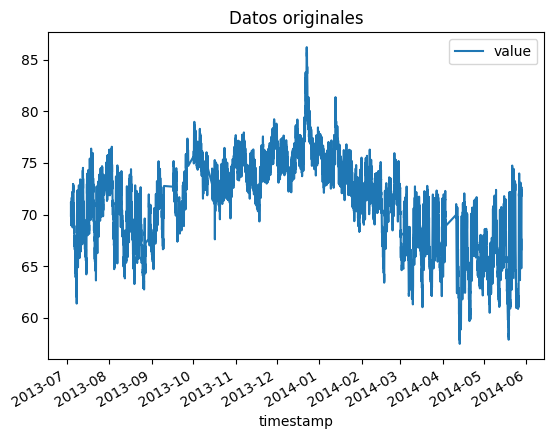

In [ ]:
# ------------------------------------------------------------------------------
# CARGA DE DATOS
# ------------------------------------------------------------------------------
print(df.head())
print(df.shape); print() # (7267,1) (según el fichero cambiará el número de filas)

df.plot()
plt.title("Datos originales")
plt.show()

# Asignamos los datos
data = df.values

Recargamos los datos para el ejercicio 3.

In [ ]:

# ------------------------------------------------------------------------------
# CONSTRUCCIÓN DEL MODELO ISOLATION FOREST
# ------------------------------------------------------------------------------
# Con 100 árboles, 1% de datos anómalos  y la semilla aleatoria
model = IsolationForest(n_estimators=100, contamination=0.01,random_state=42)

# ------------------------------------------------------------------------------
# ENTRENAMIENTO
# ------------------------------------------------------------------------------
model.fit(data)

IsolationForest(contamination=0.01, random_state=42)

Construimos un modelo de 'Isolation Forest' con un 'bosque de 100 árboles', del cual el 1% de los datos serán anómalos y con una semilla aleatoria.  
Posteriormente entrenamos el modelo con el conjunto de datos.

In [ ]:
# ------------------------------------------------------------------------------
# PREDICCIÓN Y DETECCIÓN DE ANOMALÍAS
# ------------------------------------------------------------------------------
# Predict anomalies (-1 for outliers, 1 for inliers)
y = model.predict(data)

# Filtramos la anomalías
anomalies = (y == -1)

fechas_test = df.index[:]
fechas_anomalas = fechas_test[anomalies]
valores_anomalos = data[anomalies]

print(f"El número de anomalías es {np.sum(anomalies)} sobre {len(fechas_test)}")
print("Fechas y valores anómalos detectados:")
anomalies_data_value = df.loc[fechas_test[anomalies]]
print(anomalies_data_value)

El número de anomalías es 73 sobre 7267
Fechas y valores anómalos detectados:
                         value
timestamp                     
2013-12-21 20:00:00  82.289240
2013-12-21 21:00:00  82.989869
2013-12-21 22:00:00  83.247886
2013-12-21 23:00:00  82.519659
2013-12-22 00:00:00  82.736802
...                        ...
2014-05-19 00:00:00  58.423639
2014-05-19 01:00:00  57.861906
2014-05-19 02:00:00  58.639295
2014-05-19 03:00:00  59.074691
2014-05-19 05:00:00  59.711858

[73 rows x 1 columns]


Hacemos la predicción, creamos una máscara booleana para filtrar las anomalías y creamos variables para su análisis posterior.

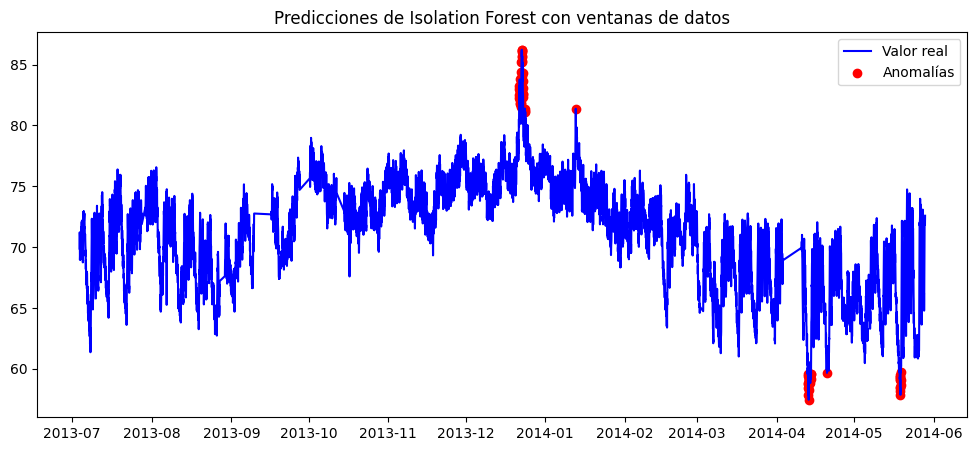

In [ ]:
# ------------------------------------------------------------------------------
# GRAFICAR RESULTADOS
# ------------------------------------------------------------------------------

plt.figure(figsize=(12,5))
plt.plot(fechas_test, data, color='blue', label='Valor real')
plt.scatter(fechas_anomalas, valores_anomalos, color='red', label='Anomalías')
plt.title("Predicciones de Isolation Forest con ventanas de datos")
plt.legend()
plt.show()

Como en los demás ejercicios, obtenemos 73 anomalías. Aunque esta vez obtenemos una gráfica idéntica a la del enunciado.  
El factor determinante para obtener este resultado ha sido el porcentaje de datos anómalos con los que creado el modelo: 1%(contamination=0.01).